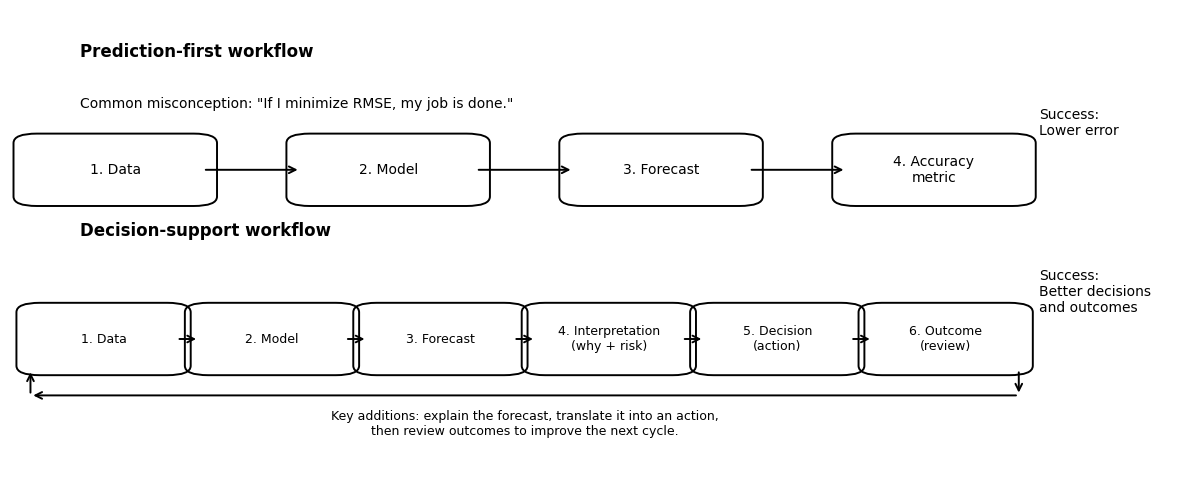

In [2]:
# Figure 1.1

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def draw_box(ax, cx, cy, w, h, text, fontsize=10, lw=1.4):
    """
    Draw a rounded rectangle centered at (cx, cy) in axes-fraction coordinates.
    This makes alignment predictable.
    """
    x = cx - w / 2
    y = cy - h / 2
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.012,rounding_size=0.02",
        linewidth=lw,
        facecolor="none",
        transform=ax.transAxes,
        clip_on=False,
    )
    ax.add_patch(box)
    ax.text(cx, cy, text, ha="center", va="center",
            fontsize=fontsize, transform=ax.transAxes)

def draw_arrow(ax, x1, y1, x2, y2, lw=1.4):
    """
    Draw an arrow between two points in axes-fraction coordinates.
    """
    arrow = FancyArrowPatch(
        (x1, y1), (x2, y2),
        arrowstyle="->",
        mutation_scale=12,
        linewidth=lw,
        transform=ax.transAxes,
        clip_on=False,
    )
    ax.add_patch(arrow)

def plot_pipeline_figure(savepath=None):
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.axis("off")

    # --- Layout (axes-fraction coordinates) ---
    left_margin = 0.06
    right_margin = 0.82  # reserve space on the far right for "Success = ..."
    y_top = 0.66
    y_bot = 0.30

    # Box sizes
    w_top, h_box = 0.15, 0.13
    w_bot = 0.125

    # Evenly spaced centers for each lane (prevents drift/misalignment)
    def evenly_spaced_centers(n, x0, x1):
        if n == 1:
            return [(x0 + x1) / 2]
        step = (x1 - x0) / (n - 1)
        return [x0 + i * step for i in range(n)]

    xs_top = evenly_spaced_centers(4, left_margin + 0.03, right_margin - 0.03)
    xs_bot = evenly_spaced_centers(6, left_margin + 0.02, right_margin - 0.02)

    # --- Titles ---
    ax.text(left_margin, 0.90, "Prediction-first workflow",
            fontsize=12, weight="bold", ha="left", transform=ax.transAxes)
    ax.text(left_margin, 0.52, "Decision-support workflow",
            fontsize=12, weight="bold", ha="left", transform=ax.transAxes)
    
    plt.subplots_adjust(bottom=0.35)  # make room for caption


    # --- Success labels (fixed alignment, right column) ---
    ax.text(0.88, 0.76, "Success:\nLower error",
            fontsize=10, ha="left", va="center", transform=ax.transAxes)
    ax.text(0.88, 0.40, "Success:\nBetter decisions\nand outcomes",
            fontsize=10, ha="left", va="center", transform=ax.transAxes)

    # --- Top lane: boxes ---
    top_labels = ["1. Data", "2. Model", "3. Forecast", "4. Accuracy\nmetric"]
    for cx, label in zip(xs_top, top_labels):
        draw_box(ax, cx, y_top, w_top, h_box, label, fontsize=10)

    # Top arrows: connect box edges (not centers) to avoid overlap
    for i in range(len(xs_top) - 1):
        x1 = xs_top[i] + w_top / 2
        x2 = xs_top[i + 1] - w_top / 2
        draw_arrow(ax, x1, y_top, x2, y_top)

    # Misconception callout (kept aligned with top lane, not floating)
    ax.text(left_margin, 0.80,
            'Common misconception: "If I minimize RMSE, my job is done."',
            fontsize=10, ha="left", va="center", transform=ax.transAxes)

    # --- Bottom lane: boxes ---
    bot_labels = [
        "1. Data",
        "2. Model",
        "3. Forecast",
        "4. Interpretation\n(why + risk)",
        "5. Decision\n(action)",
        "6. Outcome\n(review)"
    ]
    for cx, label in zip(xs_bot, bot_labels):
        draw_box(ax, cx, y_bot, w_bot, h_box, label, fontsize=9)

    # Bottom arrows
    for i in range(len(xs_bot) - 1):
        x1 = xs_bot[i] + w_bot / 2
        x2 = xs_bot[i + 1] - w_bot / 2
        draw_arrow(ax, x1, y_bot, x2, y_bot)

    # Optional: show the loop (Outcome -> Data) for "next cycle" (clean, non-overlapping)
    # Comment out if you want a strictly linear diagram.
    loop_y = y_bot - 0.12
    start_x = xs_bot[-1] + w_bot / 2
    end_x = xs_bot[0] - w_bot / 2
    # down from Outcome
    draw_arrow(ax, start_x, y_bot - h_box/2, start_x, loop_y)
    # left across
    draw_arrow(ax, start_x, loop_y, end_x, loop_y)
    # up to Data
    draw_arrow(ax, end_x, loop_y, end_x, y_bot - h_box/2)

    # Bottom callout (centered under bottom lane)
    ax.text((left_margin + right_margin) / 2, 0.12,
            "Key additions: explain the forecast, translate it into an action,\n"
            "then review outcomes to improve the next cycle.",
            fontsize=9, ha="center", va="center", transform=ax.transAxes)

    plt.tight_layout()

    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.show()

# Run
plot_pipeline_figure()



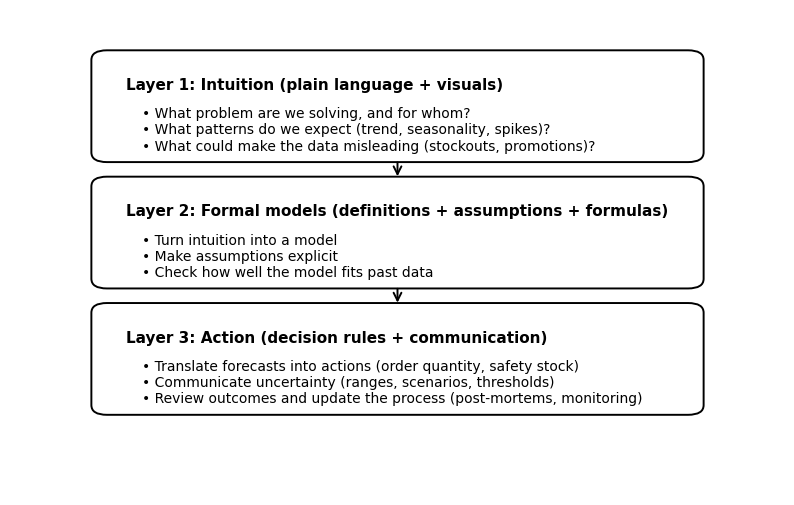

In [4]:
# Figure 1.2

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def draw_layer(ax, x, y, w, h, title, bullets, title_fs=12, bullet_fs=10, lw=1.4):
    """
    Draw a layered box with a bold title and bullet points.
    All coordinates are in axes-fraction units to avoid misalignment.
    """
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.015,rounding_size=0.02",
        linewidth=lw,
        facecolor="none",
        transform=ax.transAxes,
        clip_on=False
    )
    ax.add_patch(box)

    # Title
    ax.text(
        x + 0.03, y + h - 0.04,
        title,
        ha="left", va="top",
        fontsize=title_fs, weight="bold",
        transform=ax.transAxes
    )

    # Bullets
    bullet_text = "\n".join([f"• {b}" for b in bullets])
    ax.text(
        x + 0.05, y + h - 0.10,
        bullet_text,
        ha="left", va="top",
        fontsize=bullet_fs,
        transform=ax.transAxes
    )

def draw_down_arrow(ax, x, y1, y2, lw=1.4):
    """
    Draw a downward arrow in axes-fraction units.
    """
    arrow = FancyArrowPatch(
        (x, y1), (x, y2),
        arrowstyle="->",
        mutation_scale=14,
        linewidth=lw,
        transform=ax.transAxes,
        clip_on=False
    )
    ax.add_patch(arrow)

def plot_three_layer_figure(savepath=None):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.axis("off")

    # Reserve space (prevents overlap with bottom caption)
    plt.subplots_adjust(bottom=0.14, top=0.95)

    # Layout
    x, w = 0.12, 0.76
    h = 0.20
    y_top = 0.70
    gap = 0.06

    # Layer 1: Intuition
    draw_layer(
        ax, x, y_top, w, h,
        "Layer 1: Intuition (plain language + visuals)",
        bullets=[
            "What problem are we solving, and for whom?",
            "What patterns do we expect (trend, seasonality, spikes)?",
            "What could make the data misleading (stockouts, promotions)?"
        ],
        title_fs=11, bullet_fs=10
    )

    # Arrow
    draw_down_arrow(ax, 0.5, y_top - 0.01, y_top - gap + 0.01)

    # Layer 2: Formal models
    y_mid = y_top - (h + gap)
    draw_layer(
        ax, x, y_mid, w, h,
        "Layer 2: Formal models (definitions + assumptions + formulas)",
        bullets=[
            "Turn intuition into a model",
            "Make assumptions explicit",
            "Check how well the model fits past data"
        ],
        title_fs=11, bullet_fs=10
    )

    # Arrow
    draw_down_arrow(ax, 0.5, y_mid - 0.01, y_mid - gap + 0.01)

    # Layer 3: Action
    y_bot = y_mid - (h + gap)
    draw_layer(
        ax, x, y_bot, w, h,
        "Layer 3: Action (decision rules + communication)",
        bullets=[
            "Translate forecasts into actions (order quantity, safety stock)",
            "Communicate uncertainty (ranges, scenarios, thresholds)",
            "Review outcomes and update the process (post-mortems, monitoring)"
        ],
        title_fs=11, bullet_fs=10
    )

    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.show()


# Run
plot_three_layer_figure()


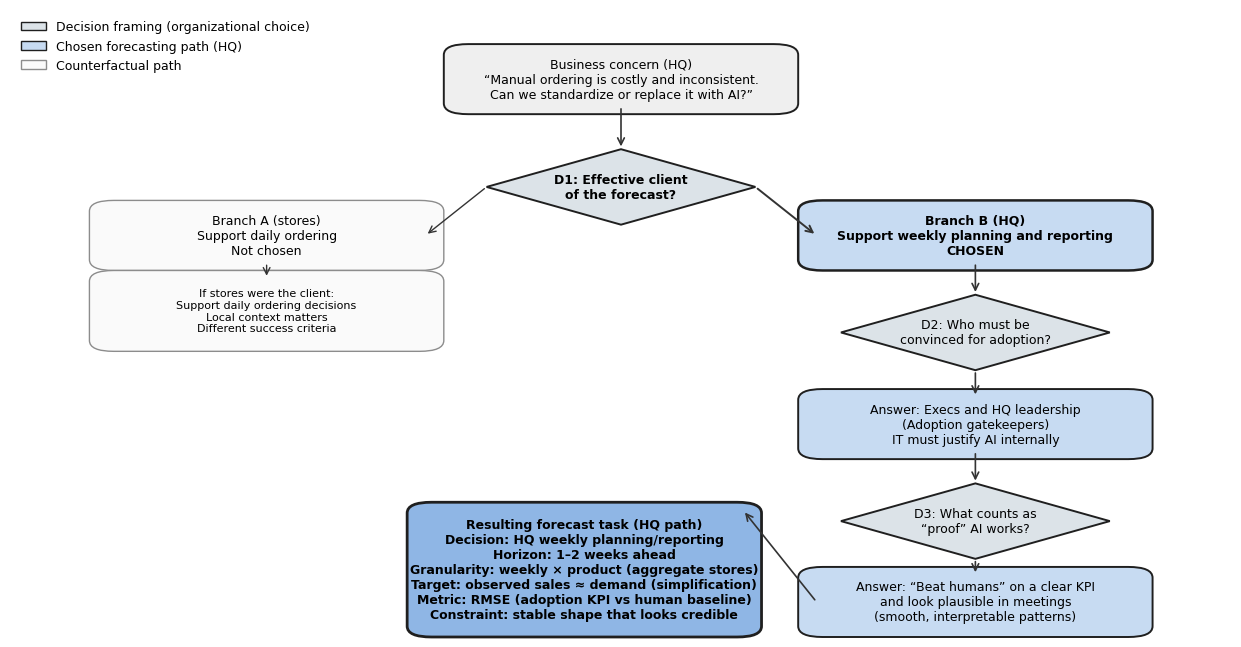

In [ ]:
# Figure 2.1

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Polygon, Patch

# -----------------------------
# Helpers (axes-fraction coords)
# -----------------------------
def draw_box(ax, x, y, w, h, text, fontsize=9, lw=1.4,
             pad=0.015, bold=False,
             facecolor="#FFFFFF", edgecolor="#000000"):
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle=f"round,pad={pad},rounding_size=0.02",
        linewidth=lw,
        facecolor=facecolor,
        edgecolor=edgecolor,
        transform=ax.transAxes,
        clip_on=False
    )
    ax.add_patch(box)
    ax.text(
        x + w/2, y + h/2, text,
        ha="center", va="center",
        fontsize=fontsize,
        fontweight=("bold" if bold else "normal"),
        transform=ax.transAxes
    )
    return (x, y, w, h)

def draw_diamond(ax, cx, cy, w, h, text, fontsize=9, lw=1.4,
                 bold=False, facecolor="#FFFFFF", edgecolor="#000000"):
    pts = [
        (cx, cy + h/2),
        (cx + w/2, cy),
        (cx, cy - h/2),
        (cx - w/2, cy),
    ]
    poly = Polygon(
        pts, closed=True,
        facecolor=facecolor,
        edgecolor=edgecolor,
        linewidth=lw,
        transform=ax.transAxes,
        clip_on=False
    )
    ax.add_patch(poly)
    ax.text(
        cx, cy, text,
        ha="center", va="center",
        fontsize=fontsize,
        fontweight=("bold" if bold else "normal"),
        transform=ax.transAxes
    )
    return (cx - w/2, cy - h/2, w, h)

def arrow(ax, x1, y1, x2, y2, lw=1.2):
    a = FancyArrowPatch(
        (x1, y1), (x2, y2),
        arrowstyle="->",
        mutation_scale=12,
        linewidth=lw,
        color="#333333",
        transform=ax.transAxes,
        clip_on=False
    )
    ax.add_patch(a)

def mid_top(b):    x,y,w,h=b; return (x+w/2, y+h)
def mid_bottom(b): x,y,w,h=b; return (x+w/2, y)
def mid_left(b):   x,y,w,h=b; return (x, y+h/2)
def mid_right(b):  x,y,w,h=b; return (x+w, y+h/2)

# -----------------------------
# Figure 2.1
# -----------------------------
def plot_figure_2_1(savepath=None):
    fig, ax = plt.subplots(figsize=(13, 7))
    ax.axis("off")
    plt.subplots_adjust(left=0.03, right=0.97, top=0.92, bottom=0.15)

    COLORS = {
        # Context / framing (neutral, background)
        "context": "#EFEFEF",

        # Decision framing (abstract, analytical → gray-green / slate)
        "decision": "#DCE3E8",          # noticeably cooler & grayer

        # Chosen HQ forecasting path (commitment → blue)
        "hq": "#C7DBF2",                # clear blue tint
        "hq_strong": "#8FB6E5",         # saturated blue for final spec

        # Counterfactual (faded, de-emphasized)
        "counterfactual": "#FAFAFA",

        # Edges
        "edge_light": "#8C8C8C",
        "edge_dark": "#1F1F1F",
    }



    # Sizes
    BW, BH = 0.26, 0.10
    DW, DH = 0.22, 0.14

    # Root
    root = draw_box(
        ax, 0.37, 0.82, BW, BH,
        "Business concern (HQ)\n"
        "“Manual ordering is costly and inconsistent.\n"
        "Can we standardize or replace it with AI?”",
        facecolor=COLORS["context"],
        edgecolor=COLORS["edge_dark"]
    )

    # D1
    d1 = draw_diamond(
        ax, 0.50, 0.67, DW, DH,
        "D1: Effective client\nof the forecast?",
        bold=True,
        facecolor=COLORS["decision"],
        edgecolor=COLORS["edge_dark"]
    )
    arrow(ax, *mid_bottom(root), *mid_top(d1))

    # Store path (counterfactual)
    store = draw_box(
        ax, 0.08, 0.53, BW, BH,
        "Branch A (stores)\nSupport daily ordering\nNot chosen",
        facecolor=COLORS["counterfactual"],
        edgecolor=COLORS["edge_light"],
        lw=1.0
    )

    store_leaf = draw_box(
        ax, 0.08, 0.38, BW, 0.12,
        "If stores were the client:\n"
        "Support daily ordering decisions\n"
        "Local context matters\n"
        "Different success criteria",
        fontsize=8,
        facecolor=COLORS["counterfactual"],
        edgecolor=COLORS["edge_light"],
        lw=1.0
    )

    arrow(ax, *mid_bottom(store), *mid_top(store_leaf), lw=1.0)

    # HQ path (chosen)
    hq = draw_box(
        ax, 0.66, 0.53, BW, BH,
        "Branch B (HQ)\nSupport weekly planning and reporting\nCHOSEN",
        bold=True,
        facecolor=COLORS["hq"],
        edgecolor=COLORS["edge_dark"],
        lw=1.8
    )

    d1_left  = (d1[0], d1[1] + d1[3]/2)
    d1_right = (d1[0] + d1[2], d1[1] + d1[3]/2)
    arrow(ax, d1_left[0], d1_left[1], *mid_right(store), lw=1.0)
    arrow(ax, d1_right[0], d1_right[1], *mid_left(hq), lw=1.4)

    # D2
    d2 = draw_diamond(
        ax, 0.79, 0.40, DW, DH,
        "D2: Who must be\nconvinced for adoption?",
        facecolor=COLORS["decision"],
        edgecolor=COLORS["edge_dark"]
    )
    arrow(ax, *mid_bottom(hq), *mid_top(d2))

    gate = draw_box(
        ax, 0.66, 0.18, BW, BH,
        "Answer: Execs and HQ leadership\n"
        "(Adoption gatekeepers)\n"
        "IT must justify AI internally",
        facecolor=COLORS["hq"],
        edgecolor=COLORS["edge_dark"]
    )
    arrow(ax, *mid_bottom(d2), *mid_top(gate))

    # D3
    d3 = draw_diamond(
        ax, 0.79, 0.05, DW, DH,
        "D3: What counts as\n“proof” AI works?",
        facecolor=COLORS["decision"],
        edgecolor=COLORS["edge_dark"]
    )
    arrow(ax, *mid_bottom(gate), *mid_top(d3))

    proof = draw_box(
        ax, 0.66, -0.15, BW, 0.10,
        "Answer: “Beat humans” on a clear KPI\n"
        "and look plausible in meetings\n"
        "(smooth, interpretable patterns)",
        facecolor=COLORS["hq"],
        edgecolor=COLORS["edge_dark"]
    )
    arrow(ax, *mid_bottom(d3), *mid_top(proof))

    # Final spec
    spec = draw_box(
        ax, 0.34, -0.15, BW, 0.22,
        "Resulting forecast task (HQ path)\n"
        "Decision: HQ weekly planning/reporting\n"
        "Horizon: 1–2 weeks ahead\n"
        "Granularity: weekly × product (aggregate stores)\n"
        "Target: observed sales ≈ demand (simplification)\n"
        "Metric: RMSE (adoption KPI vs human baseline)\n"
        "Constraint: stable shape that looks credible",
        bold=True,
        facecolor=COLORS["hq_strong"],
        edgecolor=COLORS["edge_dark"],
        lw=2.0
    )

    arrow(
        ax,
        proof[0], proof[1] + proof[3]/2,
        spec[0] + spec[2], spec[1] + spec[3]
    )

    legend_items = [
        Patch(facecolor=COLORS["decision"], edgecolor=COLORS["edge_dark"],
            label="Decision framing (organizational choice)"),
        Patch(facecolor=COLORS["hq"], edgecolor=COLORS["edge_dark"],
            label="Chosen forecasting path (HQ)"),
        Patch(facecolor=COLORS["counterfactual"], edgecolor=COLORS["edge_light"],
            label="Counterfactual path"),
    ]


    ax.legend(
        handles=legend_items,
        loc="upper left",
        frameon=False,
        fontsize=9
    )

    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.show()


# Run
plot_figure_2_1()
